# Baseline justo: ResNet puro vs DeMemte + VQ-VAE

Comparación justa usando exactamente la misma metodología para ambos modelos:
- Flowers102
- Stratified K-Fold
- Early stopping
- Mismo esquema de evaluación clean/noisy/masking

In [1]:
import os
import copy
import json
import random
from dataclasses import dataclass, asdict
from datetime import datetime

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, ConcatDataset, Subset

import torchvision
import torchvision.transforms as transforms
from sklearn.model_selection import StratifiedKFold

seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

print('torch:', torch.__version__)
print('torchvision:', torchvision.__version__)
print('cuda:', torch.cuda.is_available())

torch: 2.10.0+cu128
torchvision: 0.25.0+cu128
cuda: True


In [2]:
@dataclass
class Config:
    data_dir: str = '../data'
    num_classes: int = 102
    batch_size: int = 64
    num_workers: int = 2

    n_splits: int = 3
    cv_seed: int = 42

    lr_baseline: float = 1e-3
    lr_vq: float = 3e-4
    lr_cls: float = 1e-4
    lr_backbone: float = 2e-4
    weight_decay: float = 1e-4

    epochs_baseline_max: int = 30
    epochs_phase1_max: int = 10
    epochs_phase2_max: int = 30

    early_stop_patience: int = 3
    early_stop_min_delta: float = 1e-4

    scheduler_factor: float = 0.5
    scheduler_patience: int = 1

    feature_noise_std: float = 0.2

    embedding_dim: int = 128
    num_embeddings: int = 512
    commitment_cost: float = 0.25
    ema_decay: float = 0.99
    eps: float = 1e-5

    init_tau: float = 2.0
    init_alpha: float = 1.5

    denoise_weight: float = 0.25
    vq_weight: float = 0.25

    max_train_batches_debug: int = 10000000
    max_val_batches_debug: int = 10000000

    artifacts_root: str = './out/artifacts'
    experiment_name: str = 'baseline_vs_dememte_cv'

    device: str = 'cuda' if torch.cuda.is_available() else 'cpu'

cfg = Config()
device = torch.device(cfg.device)
criterion = nn.CrossEntropyLoss()
print(json.dumps(asdict(cfg), indent=2))

{
  "data_dir": "../data",
  "num_classes": 102,
  "batch_size": 64,
  "num_workers": 2,
  "n_splits": 3,
  "cv_seed": 42,
  "lr_baseline": 0.001,
  "lr_vq": 0.0003,
  "lr_cls": 0.0001,
  "lr_backbone": 0.0002,
  "weight_decay": 0.0001,
  "epochs_baseline_max": 30,
  "epochs_phase1_max": 10,
  "epochs_phase2_max": 30,
  "early_stop_patience": 3,
  "early_stop_min_delta": 0.0001,
  "scheduler_factor": 0.5,
  "scheduler_patience": 1,
  "feature_noise_std": 0.2,
  "embedding_dim": 128,
  "num_embeddings": 512,
  "commitment_cost": 0.25,
  "ema_decay": 0.99,
  "eps": 1e-05,
  "init_tau": 2.0,
  "init_alpha": 1.5,
  "denoise_weight": 0.25,
  "vq_weight": 0.25,
  "max_train_batches_debug": 10000000,
  "max_val_batches_debug": 10000000,
  "artifacts_root": "./out/artifacts",
  "experiment_name": "baseline_vs_dememte_cv",
  "device": "cuda"
}


In [3]:
def _extract_labels(dataset):
    if hasattr(dataset, '_labels'):
        return np.array(dataset._labels)
    if hasattr(dataset, 'labels'):
        return np.array(dataset.labels)
    ys = []
    for i in range(len(dataset)):
        _, y = dataset[i]
        ys.append(int(y))
    return np.array(ys)

def build_datasets(config: Config):
    transform_train = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    ])
    transform_eval = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    ])

    tr = torchvision.datasets.Flowers102(root=config.data_dir, split='train', download=False, transform=transform_train)
    va = torchvision.datasets.Flowers102(root=config.data_dir, split='val', download=False, transform=transform_eval)
    te = torchvision.datasets.Flowers102(root=config.data_dir, split='test', download=False, transform=transform_eval)

    cv_ds = ConcatDataset([tr, va])
    cv_y = np.concatenate([_extract_labels(tr), _extract_labels(va)], axis=0)
    testloader = DataLoader(te, batch_size=config.batch_size, shuffle=False, num_workers=config.num_workers, pin_memory=True)
    return cv_ds, cv_y, testloader

cv_dataset, cv_labels, testloader = build_datasets(cfg)
print('cv size:', len(cv_dataset), '| classes:', len(np.unique(cv_labels)))

cv size: 2040 | classes: 102


In [4]:
def make_backbone():
    base = torchvision.models.resnet18(weights=torchvision.models.ResNet18_Weights.IMAGENET1K_V1)
    return nn.Sequential(*list(base.children())[:-2])

class ResNetPureBaseline(nn.Module):
    def __init__(self, backbone, num_classes):
        super().__init__()
        self.backbone = backbone
        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        self.classifier = nn.Linear(512, num_classes)

    def forward(self, x, return_debug=False):
        feats = self.backbone(x)
        feats_flat = self.pool(feats).flatten(1)
        logits = self.classifier(feats_flat)
        if return_debug:
            return logits, {'clean_feats': feats, 'noisy_feats': feats, 'enhanced_feats': feats}
        return logits

class VectorQuantizer(nn.Module):
    def __init__(self, num_embeddings, embedding_dim, commitment_cost=0.25):
        super().__init__()
        self.num_embeddings = num_embeddings
        self.embedding_dim = embedding_dim
        self.commitment_cost = commitment_cost
        self.embedding = nn.Embedding(num_embeddings, embedding_dim)
        self.embedding.weight.data.uniform_(-1 / num_embeddings, 1 / num_embeddings)

    def forward(self, z_e):
        b, c, h, w = z_e.shape
        z_e_perm = z_e.permute(0, 2, 3, 1).contiguous()
        flat = z_e_perm.view(-1, c)
        emb = self.embedding.weight
        distances = flat.pow(2).sum(1, keepdim=True) - 2 * flat @ emb.t() + emb.pow(2).sum(1, keepdim=True).t()
        idx = torch.argmin(distances, dim=1)
        one_hot = F.one_hot(idx, self.num_embeddings).type(flat.dtype)
        q_flat = one_hot @ emb
        q = q_flat.view(b, h, w, c).permute(0, 3, 1, 2).contiguous()
        vq_loss = self.commitment_cost * F.mse_loss(z_e, q.detach()) + F.mse_loss(q, z_e.detach())
        q_st = z_e + (q - z_e).detach()
        dq_map = ((z_e - q.detach()) ** 2).mean(dim=1, keepdim=True)
        return q_st, vq_loss, dq_map

class SpatialVQVAE(nn.Module):
    def __init__(self, in_channels=512, hidden_channels=256, embedding_dim=128, num_embeddings=512, commitment_cost=0.25):
        super().__init__()
        self.encoder = nn.Sequential(nn.Conv2d(in_channels, hidden_channels, 3, padding=1), nn.BatchNorm2d(hidden_channels), nn.ReLU(inplace=True), nn.Conv2d(hidden_channels, embedding_dim, 1))
        self.vq = VectorQuantizer(num_embeddings, embedding_dim, commitment_cost)
        self.decoder = nn.Sequential(nn.Conv2d(embedding_dim, hidden_channels, 3, padding=1), nn.BatchNorm2d(hidden_channels), nn.ReLU(inplace=True), nn.Conv2d(hidden_channels, in_channels, 1))

    def forward(self, x):
        z = self.encoder(x)
        zq, vq_loss, dq_map = self.vq(z)
        x_rec = self.decoder(zq)
        return x_rec, vq_loss, dq_map

class DeMemteSpatialVQ(nn.Module):
    def __init__(self, backbone, vq_vae, num_classes):
        super().__init__()
        self.backbone = backbone
        self.vq_vae = vq_vae
        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        self.classifier = nn.Linear(512, num_classes)
        self.gate_tau = nn.Parameter(torch.tensor(0.0))
        self.gate_alpha = nn.Parameter(torch.tensor(1.5))
        self.register_buffer('dq_ema_mean', torch.tensor(0.0))
        self.register_buffer('dq_ema_var', torch.tensor(1.0))
        self.register_buffer('dq_ema_counted', torch.tensor(0.0))

    def set_backbone_trainable(self, trainable: bool):
        for p in self.backbone.parameters():
            p.requires_grad = trainable

    def _extract_backbone(self, x):
        return self.backbone(x)

    def classify_from_features(self, feats):
        rec_feats, _, dq_map = self.vq_vae(feats)
        dq_norm = (dq_map - self.dq_ema_mean) / (torch.sqrt(self.dq_ema_var) + 1e-5)
        alpha = F.softplus(self.gate_alpha)
        signal = torch.sigmoid(alpha * (dq_norm - self.gate_tau))
        enhanced = (1.0 - signal) * feats + signal * rec_feats
        out = self.classifier(self.pool(enhanced).flatten(1))
        return out

    def forward(self, x, target_feats=None, update_ema=True, return_debug=False):
        input_feats = self._extract_backbone(x)
        rec_feats, vq_loss, dq_map = self.vq_vae(input_feats)

        target = input_feats.detach() if target_feats is None else target_feats.detach()
        denoise_loss = F.mse_loss(rec_feats, target)

        if self.training and update_ema:
            with torch.no_grad():
                batch_mean = dq_map.mean()
                batch_var = dq_map.var(unbiased=False) if dq_map.numel() > 1 else torch.tensor(0.0, device=dq_map.device)
                momentum = 0.99
                if self.dq_ema_counted.item() == 0:
                    self.dq_ema_mean.fill_(batch_mean)
                    self.dq_ema_var.fill_(batch_var)
                else:
                    self.dq_ema_mean.mul_(momentum).add_(batch_mean * (1 - momentum))
                    self.dq_ema_var.mul_(momentum).add_(batch_var * (1 - momentum))
                self.dq_ema_counted.add_(1.0)

        dq_norm = (dq_map - self.dq_ema_mean) / (torch.sqrt(self.dq_ema_var) + 1e-5)
        alpha = F.softplus(self.gate_alpha)
        signal = torch.sigmoid(alpha * (dq_norm - self.gate_tau))
        enhanced = (1.0 - signal) * input_feats + signal * rec_feats
        feat_flat = self.pool(enhanced).flatten(1)
        logits = self.classifier(feat_flat)
        if return_debug:
            return logits, denoise_loss, vq_loss, {'clean_feats': input_feats, 'noisy_feats': input_feats, 'enhanced_feats': enhanced, 'signal': signal}
        return logits, denoise_loss, vq_loss

In [ ]:
def make_baseline(config: Config):
    model = ResNetPureBaseline(make_backbone(), config.num_classes).to(device)
    optimizer = optim.AdamW(model.parameters(), lr=config.lr_baseline, weight_decay=config.weight_decay)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode='min',
        factor=config.scheduler_factor,
        patience=config.scheduler_patience,
    )
    return model, optimizer, scheduler


def make_dememte(config: Config):
    model = DeMemteSpatialVQ(
        make_backbone(),
        SpatialVQVAE(
            in_channels=512,
            hidden_channels=256,
            embedding_dim=config.embedding_dim,
            num_embeddings=config.num_embeddings,
            commitment_cost=config.commitment_cost,
        ),
        config.num_classes,
    ).to(device)

    model.gate_tau.data.fill_(config.init_tau)
    model.gate_alpha.data.fill_(config.init_alpha)

    vq_params = list(model.vq_vae.parameters())
    cls_params = [
        *model.classifier.parameters(),
        model.gate_tau,
        model.gate_alpha,
    ]

    model.set_backbone_trainable(False)
    optimizer_p1 = optim.AdamW(vq_params, lr=config.lr_vq, weight_decay=config.weight_decay)
    scheduler_p1 = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer_p1,
        mode='min',
        factor=config.scheduler_factor,
        patience=config.scheduler_patience,
    )

    optimizer_p2 = optim.AdamW([
        {'params': vq_params, 'lr': config.lr_vq},
        {'params': cls_params, 'lr': config.lr_cls},
    ], weight_decay=config.weight_decay)
    scheduler_p2 = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer_p2,
        mode='max',
        factor=config.scheduler_factor,
        patience=config.scheduler_patience,
    )

    return model, optimizer_p1, scheduler_p1, optimizer_p2, scheduler_p2


def warmstart_dememte_from_baseline(baseline_model, dememte_model):
    dememte_model.backbone.load_state_dict(copy.deepcopy(baseline_model.backbone.state_dict()))
    dememte_model.classifier.load_state_dict(copy.deepcopy(baseline_model.classifier.state_dict()))

    b_backbone_param = next(baseline_model.backbone.parameters())
    d_backbone_param = next(dememte_model.backbone.parameters())
    b_head_param = next(baseline_model.classifier.parameters())
    d_head_param = next(dememte_model.classifier.parameters())

    if b_backbone_param.data_ptr() == d_backbone_param.data_ptr() or b_head_param.data_ptr() == d_head_param.data_ptr():
        raise RuntimeError('Baseline y DeMemte comparten memoria de parámetros, lo cual no está permitido.')


def run_epoch_baseline(model, loader, optimizer, train):
    model.train(train)
    totals = {'loss': 0.0, 'acc': 0.0, 'n': 0}  

    for bi, (x, y) in enumerate(loader):
        if train and bi >= cfg.max_train_batches_debug:
            break
        if (not train) and bi >= cfg.max_val_batches_debug:
            break

        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        if train:
            optimizer.zero_grad(set_to_none=True)

        logits = model(x)
        loss = criterion(logits, y)

        if train:
            loss.backward()
            optimizer.step()

        bs = x.size(0)
        acc = (logits.argmax(1) == y).float().mean().item()
        totals['loss'] += loss.item() * bs
        totals['acc'] += acc * bs
        totals['n'] += bs

    totals['loss'] /= max(1, totals['n'])
    totals['acc'] /= max(1, totals['n'])
    return totals


def run_epoch_dememte_p1(model, loader, optimizer, train):
    model.train(train)
    model.set_backbone_trainable(False)
    totals = {'loss': 0.0, 'n': 0}

    for bi, (x, _) in enumerate(loader):
        if train and bi >= cfg.max_train_batches_debug:
            break
        if (not train) and bi >= cfg.max_val_batches_debug:
            break

        x = x.to(device, non_blocking=True)

        if train:
            optimizer.zero_grad(set_to_none=True)

        _, denoise_loss, vq_loss = model(x)
        loss = cfg.denoise_weight * denoise_loss + cfg.vq_weight * vq_loss

        if train:
            loss.backward()
            optimizer.step()

        bs = x.size(0)
        totals['loss'] += loss.item() * bs
        totals['n'] += bs

    totals['loss'] /= max(1, totals['n'])
    return totals


def run_epoch_dememte_p2(model, loader, optimizer, train):
    model.train(train)
    model.set_backbone_trainable(False)

    totals = {'loss': 0.0, 'acc': 0.0, 'n': 0}

    for bi, (x, y) in enumerate(loader):
        if train and bi >= cfg.max_train_batches_debug:
            break
        if (not train) and bi >= cfg.max_val_batches_debug:
            break

        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)
        x_clean = x
        x_noisy = x

        if train and random.random() < 0.5:
            if random.random() < 0.5:
                x_noisy = x_noisy + 1.0 * torch.randn_like(x_noisy)
            else:
                b, _, h, w = x_noisy.shape
                mask = torch.ones((b, 1, h, w), device=x_noisy.device, dtype=x_noisy.dtype)
                cut_h, cut_w = int(h * 0.3), int(w * 0.3)
                for i in range(b):
                    t = random.randint(0, h - cut_h)
                    l = random.randint(0, w - cut_w)
                    mask[i, :, t:t + cut_h, l:l + cut_w] = 0.0
                x_noisy = x_noisy * mask

        if train:
            optimizer.zero_grad(set_to_none=True)

        logits_clean, denoise_clean, vq_clean, dbg_clean = model(
            x_clean, target_feats=None, update_ema=True, return_debug=True
        )
        ce_clean = criterion(logits_clean, y)

        clean_target_feats = dbg_clean['clean_feats'].detach()
        logits_noisy, denoise_noisy, vq_noisy = model(
            x_noisy, target_feats=clean_target_feats, update_ema=False
        )
        ce_noisy = criterion(logits_noisy, y)

        cls_loss = 0.5 * (ce_clean + ce_noisy)
        denoise_loss = 0.5 * (denoise_clean + denoise_noisy)
        vq_loss = 0.5 * (vq_clean + vq_noisy)
        loss = cls_loss + cfg.denoise_weight * denoise_loss + cfg.vq_weight * vq_loss

        if train:
            loss.backward()
            optimizer.step()

        bs = x.size(0)
        acc_clean = (logits_clean.argmax(1) == y).float().mean().item()
        acc_noisy = (logits_noisy.argmax(1) == y).float().mean().item()
        acc = 0.5 * (acc_clean + acc_noisy)
        totals['loss'] += loss.item() * bs
        totals['acc'] += acc * bs
        totals['n'] += bs

    totals['loss'] /= max(1, totals['n'])
    totals['acc'] /= max(1, totals['n'])
    return totals


def eval_clean_acc(model, loader, max_batches=10):
    model.eval()
    correct, total = 0, 0

    with torch.no_grad():
        for bi, (x, y) in enumerate(loader):
            if bi >= max_batches:
                break

            x = x.to(device, non_blocking=True)
            y = y.to(device, non_blocking=True)

            if isinstance(model, ResNetPureBaseline):
                logits = model(x)
            else:
                logits, _, _ = model(x)

            correct += (logits.argmax(1) == y).sum().item()
            total += y.size(0)

    return correct / max(1, total)

In [6]:
run_stamp = datetime.now().strftime('%Y%m%d_%H%M%S')
artifacts_dir = os.path.join(cfg.artifacts_root, f'{cfg.experiment_name}_{run_stamp}')
os.makedirs(artifacts_dir, exist_ok=True)

skf = StratifiedKFold(n_splits=cfg.n_splits, shuffle=True, random_state=cfg.cv_seed)
results = {'baseline': [], 'dememte': []}
best_baseline = {'val_acc': -1.0, 'fold': None, 'state': None}
best_dememte = {'val_acc': -1.0, 'fold': None, 'state': None}

for fold, (train_idx, val_idx) in enumerate(skf.split(np.zeros(len(cv_labels)), cv_labels), start=1):
    print(f'\n===== Fold {fold}/{cfg.n_splits} =====')
    tr_ds = Subset(cv_dataset, train_idx.tolist())
    va_ds = Subset(cv_dataset, val_idx.tolist())

    tr_loader = DataLoader(tr_ds, batch_size=cfg.batch_size, shuffle=True, num_workers=cfg.num_workers, pin_memory=True)
    va_loader = DataLoader(va_ds, batch_size=cfg.batch_size, shuffle=False, num_workers=cfg.num_workers, pin_memory=True)

    # Baseline puro (instancia independiente)
    b_model, b_opt, b_sch = make_baseline(cfg)
    best_b_acc, best_b_state, no_imp = -1.0, copy.deepcopy(b_model.state_dict()), 0

    for ep in range(1, cfg.epochs_baseline_max + 1):
        tr = run_epoch_baseline(b_model, tr_loader, b_opt, train=True)
        va = run_epoch_baseline(b_model, va_loader, b_opt, train=False)
        b_sch.step(va['loss'])
        print(f"[Fold {fold} | Baseline {ep:02d}] tr_acc={tr['acc']:.4f} val_acc={va['acc']:.4f}")
        if va['acc'] > best_b_acc + cfg.early_stop_min_delta:
            best_b_acc = va['acc']
            best_b_state = copy.deepcopy(b_model.state_dict())
            no_imp = 0
        else:
            no_imp += 1
            if no_imp >= cfg.early_stop_patience:
                print(f'Baseline early stop en época {ep}.')
                break

    b_model.load_state_dict(best_b_state)
    b_val = eval_clean_acc(b_model, va_loader, max_batches=cfg.max_val_batches_debug)
    b_test = eval_clean_acc(b_model, testloader, max_batches=cfg.max_val_batches_debug)
    results['baseline'].append({'fold': fold, 'val_acc': float(b_val), 'test_acc_debug': float(b_test)})
    if b_val > best_baseline['val_acc']:
        best_baseline = {'val_acc': b_val, 'fold': fold, 'state': copy.deepcopy(best_b_state)}

    # DeMemte (segunda instancia independiente de ResNet como backbone)
    d_model, d_opt1, d_sch1, d_opt2, d_sch2 = make_dememte(cfg)

    # Warmstart por transferencia de pesos (sin compartir memoria)
    warmstart_dememte_from_baseline(b_model, d_model)

    best_p1, best_p1_state, no_imp1 = float('inf'), copy.deepcopy(d_model.state_dict()), 0
    for ep in range(1, cfg.epochs_phase1_max + 1):
        tr = run_epoch_dememte_p1(d_model, tr_loader, d_opt1, train=True)
        va = run_epoch_dememte_p1(d_model, va_loader, d_opt1, train=False)
        d_sch1.step(va['loss'])
        print(f"[Fold {fold} | DeMemte P1 {ep:02d}] tr_loss={tr['loss']:.4f} val_loss={va['loss']:.4f}")
        if va['loss'] < best_p1 - cfg.early_stop_min_delta:
            best_p1 = va['loss']
            best_p1_state = copy.deepcopy(d_model.state_dict())
            no_imp1 = 0
        else:
            no_imp1 += 1
            if no_imp1 >= cfg.early_stop_patience:
                print(f'DeMemte P1 early stop en época {ep}.')
                break

    d_model.load_state_dict(best_p1_state)

    best_p2, best_p2_state, no_imp2 = -1.0, copy.deepcopy(d_model.state_dict()), 0
    for ep in range(1, cfg.epochs_phase2_max + 1):
        tr = run_epoch_dememte_p2(d_model, tr_loader, d_opt2, train=True)
        va = run_epoch_dememte_p2(d_model, va_loader, d_opt2, train=False)
        d_sch2.step(va['acc'])
        print(f"[Fold {fold} | DeMemte P2 {ep:02d}] tr_acc={tr['acc']:.4f} val_acc={va['acc']:.4f}")
        if va['acc'] > best_p2 + cfg.early_stop_min_delta:
            best_p2 = va['acc']
            best_p2_state = copy.deepcopy(d_model.state_dict())
            no_imp2 = 0
        else:
            no_imp2 += 1
            if no_imp2 >= cfg.early_stop_patience:
                print(f'DeMemte P2 early stop en época {ep}.')
                break

    d_model.load_state_dict(best_p2_state)
    d_val = eval_clean_acc(d_model, va_loader, max_batches=cfg.max_val_batches_debug)
    d_test = eval_clean_acc(d_model, testloader, max_batches=cfg.max_val_batches_debug)
    results['dememte'].append({'fold': fold, 'val_acc': float(d_val), 'test_acc_debug': float(d_test)})
    if d_val > best_dememte['val_acc']:
        best_dememte = {'val_acc': d_val, 'fold': fold, 'state': copy.deepcopy(best_p2_state)}

    print(f'[Fold {fold}] baseline_val={b_val:.4f} | dememte_val={d_val:.4f}')

summary = {
    'config': asdict(cfg),
    'results': results,
    'best_baseline_fold': best_baseline['fold'],
    'best_baseline_val_acc': float(best_baseline['val_acc']),
    'best_dememte_fold': best_dememte['fold'],
    'best_dememte_val_acc': float(best_dememte['val_acc']),
}

summary_path = os.path.join(artifacts_dir, 'baseline_vs_dememte_cv_metrics.json')
with open(summary_path, 'w', encoding='utf-8') as f:
    json.dump(summary, f, ensure_ascii=False, indent=2)

torch.save({'state_dict': best_baseline['state'], 'fold': best_baseline['fold'], 'config': asdict(cfg)}, os.path.join(artifacts_dir, 'best_baseline.pt'))
torch.save({'state_dict': best_dememte['state'], 'fold': best_dememte['fold'], 'config': asdict(cfg)}, os.path.join(artifacts_dir, 'best_dememte.pt'))

print('\n===== RESUMEN CV =====')
print('Baseline best fold/acc:', best_baseline['fold'], float(best_baseline['val_acc']))
print('DeMemte best fold/acc:', best_dememte['fold'], float(best_dememte['val_acc']))
print('artifact dir:', artifacts_dir)
print('summary:', summary_path)


===== Fold 1/3 =====
[Fold 1 | Baseline 01] tr_acc=0.3632 val_acc=0.4191
[Fold 1 | Baseline 02] tr_acc=0.8493 val_acc=0.5971
[Fold 1 | Baseline 03] tr_acc=0.9493 val_acc=0.7426
[Fold 1 | Baseline 04] tr_acc=0.9809 val_acc=0.8015
[Fold 1 | Baseline 05] tr_acc=0.9912 val_acc=0.7824
[Fold 1 | Baseline 06] tr_acc=0.9949 val_acc=0.7618
[Fold 1 | Baseline 07] tr_acc=0.9934 val_acc=0.8162
[Fold 1 | Baseline 08] tr_acc=0.9978 val_acc=0.8603
[Fold 1 | Baseline 09] tr_acc=0.9993 val_acc=0.8897
[Fold 1 | Baseline 10] tr_acc=1.0000 val_acc=0.8824
[Fold 1 | Baseline 11] tr_acc=1.0000 val_acc=0.8897
[Fold 1 | Baseline 12] tr_acc=1.0000 val_acc=0.8868
Baseline early stop en época 12.
[Fold 1 | DeMemte P1 01] tr_loss=0.8064 val_loss=1.3706
[Fold 1 | DeMemte P1 02] tr_loss=0.9070 val_loss=1.1076
[Fold 1 | DeMemte P1 03] tr_loss=1.1781 val_loss=1.2097
[Fold 1 | DeMemte P1 04] tr_loss=1.5092 val_loss=1.3026
[Fold 1 | DeMemte P1 05] tr_loss=1.7941 val_loss=1.4735
DeMemte P1 early stop en época 5.
[Fold 1

Evaluando robustez a Image-Level Noise...
Evaluando robustez a Image-Level Masking...


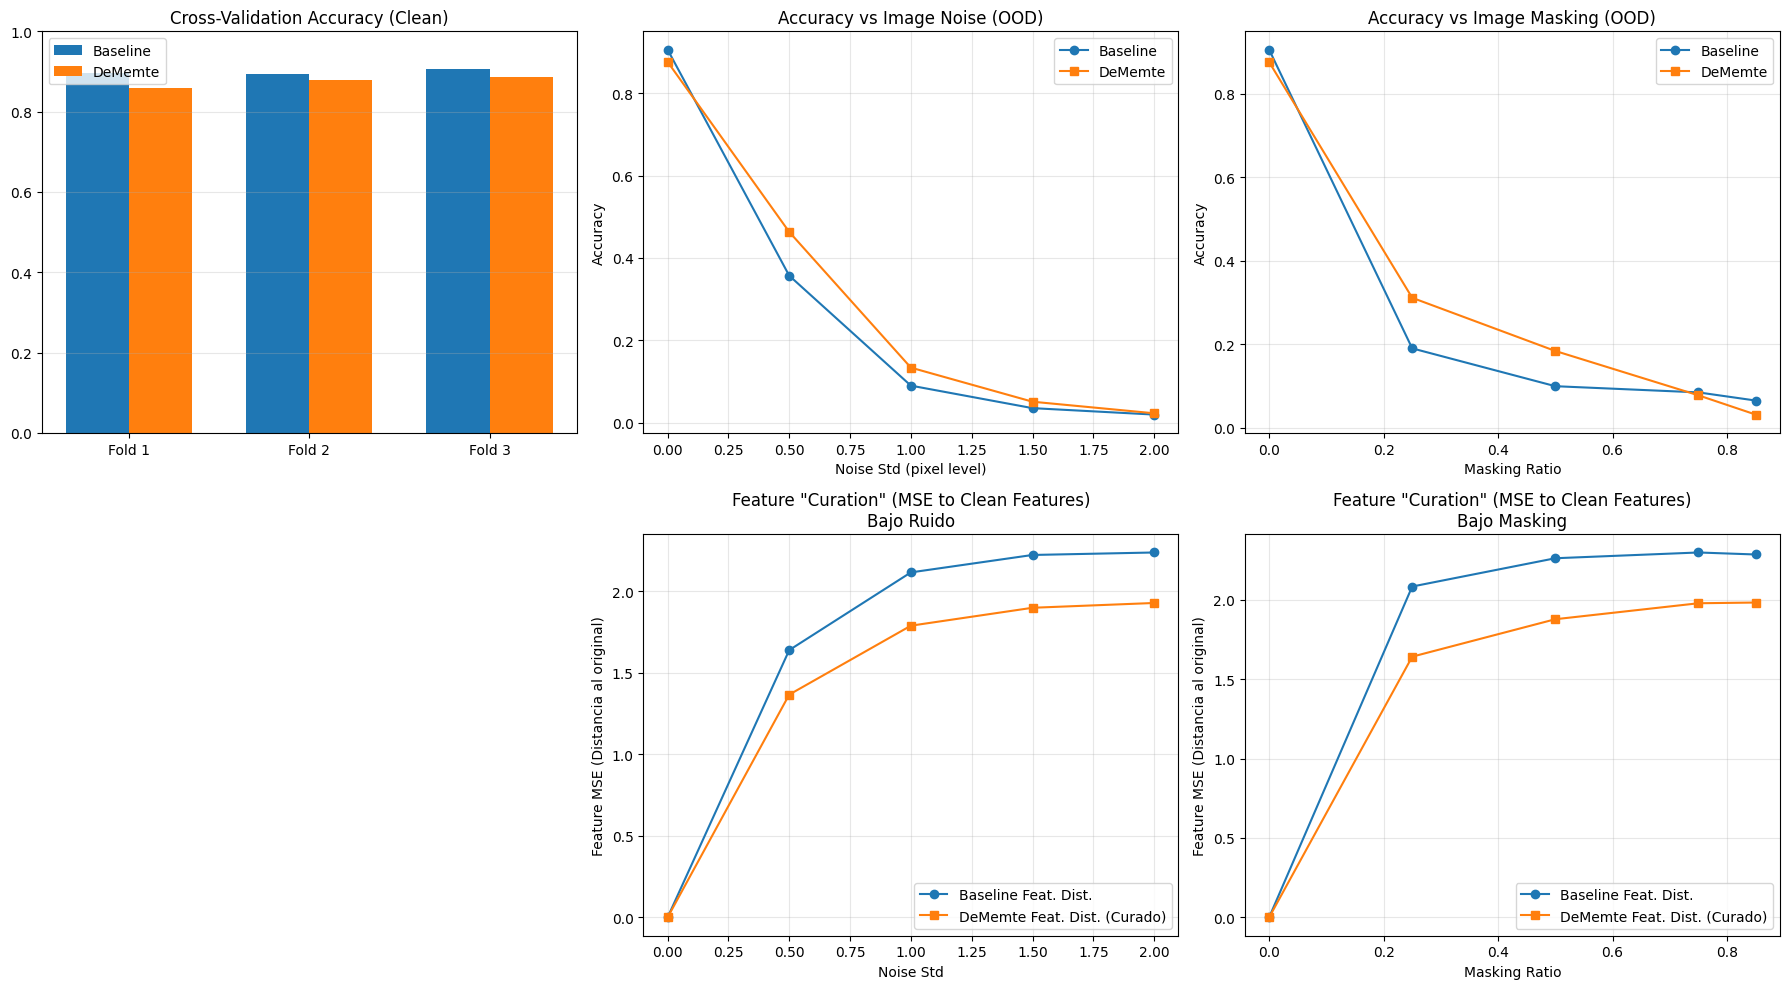

--- EXPERIMENTO DE ROBUSTEZ Y CURACIÓN ---
DeMemte Feature MSE a 1.5 Noise: 1.8977 vs Baseline: 2.2212
DeMemte Feature MSE a 0.75 Mask: 1.9767 vs Baseline: 2.2961


In [7]:
baseline_model, _, _ = make_baseline(cfg)
baseline_model.load_state_dict(best_baseline['state'])
baseline_model.eval()

dememte_model, _, _, _, _ = make_dememte(cfg)
dememte_model.load_state_dict(best_dememte['state'])
dememte_model.eval()

def eval_robustness(model, loader, corruption_type, level, max_batches=20):
    clean_correct, cor_correct = 0, 0
    total = 0
    feature_mse_sum = 0.0
    
    with torch.no_grad():
        for bi, (x, y) in enumerate(loader):
            if bi >= max_batches: break
            x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
            
            # Apply corruption to INPUT IMAGES
            if corruption_type == 'noise':
                # noise is standardized to ResNet input variance (~0.22)
                # level 1.0 means std=~0.22*1.0 pixel noise
                x_cor = x + level * torch.randn_like(x)
            elif corruption_type == 'mask':
                # Random pixel-level masking simulating severe occlusion/packet loss
                b, c, h, w = x.shape
                keep = (torch.rand(b, 1, h, w, device=x.device) > level).float()
                x_cor = x * keep 
            else:
                x_cor = x
            
            # Forward Clean vs Corrupt
            if isinstance(model, ResNetPureBaseline):
                logits_clean, dbg_clean = model(x, return_debug=True)
                logits_cor, dbg_cor = model(x_cor, return_debug=True)
            else:
                logits_clean, _, _, dbg_clean = model(x, return_debug=True)
                logits_cor, _, _, dbg_cor = model(x_cor, return_debug=True)
                
            clean_correct += (logits_clean.argmax(1) == y).sum().item()
            cor_correct += (logits_cor.argmax(1) == y).sum().item()
            total += y.size(0)
            
            # Distance between Features of (Clean Image) vs (Corrupted Image)
            feat_clean = dbg_clean['enhanced_feats']
            feat_cor = dbg_cor['enhanced_feats']
            mse = F.mse_loss(feat_cor, feat_clean)
            feature_mse_sum += mse.item() * y.size(0)
            
    return {
        'clean_acc': clean_correct / max(1, total),
        'corrupt_acc': cor_correct / max(1, total),
        'feature_mse': feature_mse_sum / max(1, total)
    }

image_noise_levels = [0.0, 0.5, 1.0, 1.5, 2.0]
image_mask_levels = [0.0, 0.25, 0.5, 0.75, 0.85]

print("Evaluando robustez a Image-Level Noise...")
b_noise = [eval_robustness(baseline_model, testloader, 'noise', n) for n in image_noise_levels]
d_noise = [eval_robustness(dememte_model, testloader, 'noise', n) for n in image_noise_levels]

print("Evaluando robustez a Image-Level Masking...")
b_mask = [eval_robustness(baseline_model, testloader, 'mask', m) for m in image_mask_levels]
d_mask = [eval_robustness(dememte_model, testloader, 'mask', m) for m in image_mask_levels]

# ---------------- PLOTTING ----------------
b_vals = [r['val_acc'] for r in results['baseline']]
d_vals = [r['val_acc'] for r in results['dememte']]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. CV Results
ax = axes[0, 0]
w = 0.35
ix = np.arange(cfg.n_splits)
ax.bar(ix - w/2, b_vals, width=w, label='Baseline')
ax.bar(ix + w/2, d_vals, width=w, label='DeMemte')
ax.set_xticks(ix)
ax.set_xticklabels([f'Fold {f+1}' for f in range(cfg.n_splits)])
ax.set_ylim(0.0, 1.0)
ax.set_title('Cross-Validation Accuracy (Clean)')
ax.legend()
ax.grid(axis='y', alpha=0.3)

# 2. Image Noise Acc
ax = axes[0, 1]
ax.plot(image_noise_levels, [x['corrupt_acc'] for x in b_noise], marker='o', label='Baseline')
ax.plot(image_noise_levels, [x['corrupt_acc'] for x in d_noise], marker='s', label='DeMemte')
ax.set_title('Accuracy vs Image Noise (OOD)')
ax.set_xlabel('Noise Std (pixel level)')
ax.set_ylabel('Accuracy')
ax.legend()
ax.grid(alpha=0.3)

# 3. Image Mask Acc
ax = axes[0, 2]
ax.plot(image_mask_levels, [x['corrupt_acc'] for x in b_mask], marker='o', label='Baseline')
ax.plot(image_mask_levels, [x['corrupt_acc'] for x in d_mask], marker='s', label='DeMemte')
ax.set_title('Accuracy vs Image Masking (OOD)')
ax.set_xlabel('Masking Ratio')
ax.set_ylabel('Accuracy')
ax.legend()
ax.grid(alpha=0.3)

# 4. Feature MSE under Noise
ax = axes[1, 1]
ax.plot(image_noise_levels, [x['feature_mse'] for x in b_noise], marker='o', label='Baseline Feat. Dist.')
ax.plot(image_noise_levels, [x['feature_mse'] for x in d_noise], marker='s', label='DeMemte Feat. Dist. (Curado)')
ax.set_title('Feature "Curation" (MSE to Clean Features)\nBajo Ruido')
ax.set_xlabel('Noise Std')
ax.set_ylabel('Feature MSE (Distancia al original)')
ax.legend()
ax.grid(alpha=0.3)

# 5. Feature MSE under Masking
ax = axes[1, 2]
ax.plot(image_mask_levels, [x['feature_mse'] for x in b_mask], marker='o', label='Baseline Feat. Dist.')
ax.plot(image_mask_levels, [x['feature_mse'] for x in d_mask], marker='s', label='DeMemte Feat. Dist. (Curado)')
ax.set_title('Feature "Curation" (MSE to Clean Features)\nBajo Masking')
ax.set_xlabel('Masking Ratio')
ax.set_ylabel('Feature MSE (Distancia al original)')
ax.legend()
ax.grid(alpha=0.3)

axes[1, 0].axis('off') # Hide empty plot
plt.tight_layout()
plt.show()

print('--- EXPERIMENTO DE ROBUSTEZ Y CURACIÓN ---')
print(f"DeMemte Feature MSE a {image_noise_levels[-2]} Noise: {d_noise[-2]['feature_mse']:.4f} vs Baseline: {b_noise[-2]['feature_mse']:.4f}")
print(f"DeMemte Feature MSE a {image_mask_levels[-2]} Mask: {d_mask[-2]['feature_mse']:.4f} vs Baseline: {b_mask[-2]['feature_mse']:.4f}")


In [8]:
# Robustez estricta: corrupción pareada + todo el test set + corrupciones más desafiantes

baseline_model.eval()
dememte_model.eval()

def _predict_logits(model, x):
    if isinstance(model, ResNetPureBaseline):
        return model(x)
    logits, _, _ = model(x)
    return logits

def _gaussian_blur_batch(x, kernel_size=7):
    pad = kernel_size // 2
    channels = x.size(1)
    weight = torch.ones(channels, 1, kernel_size, kernel_size, device=x.device, dtype=x.dtype)
    weight = weight / (kernel_size * kernel_size)
    return F.conv2d(x, weight, padding=pad, groups=channels)

def _apply_corruption(x, corruption, severity, generator):
    if corruption == 'gaussian_noise':
        x_cor = x + severity * torch.randn_like(x)
        return x_cor

    if corruption == 'pixel_mask':
        b, _, h, w = x.shape
        keep = (torch.rand(b, 1, h, w, device=x.device, generator=generator) > severity).float()
        return x * keep

    if corruption == 'cutout':
        b, _, h, w = x.shape
        cut_h = max(1, int(h * severity))
        cut_w = max(1, int(w * severity))
        mask = torch.ones((b, 1, h, w), device=x.device, dtype=x.dtype)
        max_top = max(1, h - cut_h + 1)
        max_left = max(1, w - cut_w + 1)
        tops = torch.randint(0, max_top, (b,), device=x.device, generator=generator)
        lefts = torch.randint(0, max_left, (b,), device=x.device, generator=generator)
        for i in range(b):
            t, l = tops[i].item(), lefts[i].item()
            mask[i, :, t:t + cut_h, l:l + cut_w] = 0.0
        return x * mask

    if corruption == 'blur':
        # severity in [0, 1]: mezcla entre imagen original y versión borrosa
        blur = _gaussian_blur_batch(x, kernel_size=7)
        return (1.0 - severity) * x + severity * blur

    raise ValueError(f'Corruption desconocida: {corruption}')

@torch.no_grad()    
def eval_paired_robustness(b_model, d_model, loader, corruption, levels, base_seed=1234):
    records = []
    for li, level in enumerate(levels):
        clean_b_correct = 0
        clean_d_correct = 0
        cor_b_correct = 0
        cor_d_correct = 0
        total = 0

        # seed fijo por tipo+nivel para reproducibilidad
        g = torch.Generator(device=device)
        g.manual_seed(base_seed + li * 97 + sum(ord(c) for c in corruption))

        for x, y in loader:
            x = x.to(device, non_blocking=True)
            y = y.to(device, non_blocking=True)

            x_cor = _apply_corruption(x, corruption, level, g)

            b_clean = _predict_logits(b_model, x)
            d_clean = _predict_logits(d_model, x)
            b_cor = _predict_logits(b_model, x_cor)
            d_cor = _predict_logits(d_model, x_cor)

            clean_b_correct += (b_clean.argmax(1) == y).sum().item()
            clean_d_correct += (d_clean.argmax(1) == y).sum().item()
            cor_b_correct += (b_cor.argmax(1) == y).sum().item()
            cor_d_correct += (d_cor.argmax(1) == y).sum().item()
            total += y.size(0)

        clean_b = clean_b_correct / max(1, total)
        clean_d = clean_d_correct / max(1, total)
        cor_b = cor_b_correct / max(1, total)
        cor_d = cor_d_correct / max(1, total)

        records.append({
            'corruption': corruption,
            'level': float(level),
            'baseline_clean_acc': clean_b,
            'dememte_clean_acc': clean_d,
            'baseline_corrupt_acc': cor_b,
            'dememte_corrupt_acc': cor_d,
            'dememte_minus_baseline': cor_d - cor_b,
            'baseline_drop': clean_b - cor_b,
            'dememte_drop': clean_d - cor_d,
        })
    return records

strict_suite = {
    'gaussian_noise': [0.5, 1.0, 1.5],
    'pixel_mask': [0.25, 0.5, 0.75],
    'cutout': [0.2, 0.35, 0.5],
    'blur': [0.35, 0.6, 0.85],
}

strict_results = []
for corr, levels in strict_suite.items():
    print(f'Evaluando {corr} con niveles {levels} ...')
    strict_results.extend(eval_paired_robustness(baseline_model, dememte_model, testloader, corr, levels))

print('\n===== ROBUSTEZ ESTRICTA (PAIRED / FULL TEST) =====')

for corr in strict_suite.keys():
    rows = [r for r in strict_results if r['corruption'] == corr]
    mean_b = float(np.mean([r['baseline_corrupt_acc'] for r in rows]))
    mean_d = float(np.mean([r['dememte_corrupt_acc'] for r in rows]))
    mean_adv = float(np.mean([r['dememte_minus_baseline'] for r in rows]))
    mean_drop_b = float(np.mean([r['baseline_drop'] for r in rows]))
    mean_drop_d = float(np.mean([r['dememte_drop'] for r in rows]))

    print(f'\n[{corr}]')
    print(f'  Avg corrupt acc  | Baseline: {mean_b:.4f} | DeMemte: {mean_d:.4f} | Delta(D-B): {mean_adv:+.4f}')
    print(f'  Avg clean->corrupt drop | Baseline: {mean_drop_b:.4f} | DeMemte: {mean_drop_d:.4f}')
    for r in rows:
        print(f"    level={r['level']:.2f} | B={r['baseline_corrupt_acc']:.4f} | D={r['dememte_corrupt_acc']:.4f} | D-B={r['dememte_minus_baseline']:+.4f}")

overall_b = float(np.mean([r['baseline_corrupt_acc'] for r in strict_results]))
overall_d = float(np.mean([r['dememte_corrupt_acc'] for r in strict_results]))
overall_adv = overall_d - overall_b

print('\n===== OVERALL =====')
print(f'Overall avg corrupt acc | Baseline: {overall_b:.4f} | DeMemte: {overall_d:.4f} | Delta(D-B): {overall_adv:+.4f}')
if overall_adv > 0:
    print('Conclusión: DeMemte supera en robustez promedio bajo este benchmark estricto.')
elif overall_adv < 0:
    print('Conclusión: Baseline supera en robustez promedio bajo este benchmark estricto.')
else:
    print('Conclusión: Empate exacto en robustez promedio bajo este benchmark estricto.')

Evaluando gaussian_noise con niveles [0.5, 1.0, 1.5] ...
Evaluando pixel_mask con niveles [0.25, 0.5, 0.75] ...
Evaluando cutout con niveles [0.2, 0.35, 0.5] ...
Evaluando blur con niveles [0.35, 0.6, 0.85] ...

===== ROBUSTEZ ESTRICTA (PAIRED / FULL TEST) =====

[gaussian_noise]
  Avg corrupt acc  | Baseline: 0.0620 | DeMemte: 0.0897 | Delta(D-B): +0.0276
  Avg clean->corrupt drop | Baseline: 0.8159 | DeMemte: 0.7619
    level=0.50 | B=0.1443 | D=0.2034 | D-B=+0.0592
    level=1.00 | B=0.0332 | D=0.0512 | D-B=+0.0181
    level=1.50 | B=0.0086 | D=0.0143 | D-B=+0.0057

[pixel_mask]
  Avg corrupt acc  | Baseline: 0.0452 | DeMemte: 0.0814 | Delta(D-B): +0.0363
  Avg clean->corrupt drop | Baseline: 0.8327 | DeMemte: 0.7701
    level=0.25 | B=0.0758 | D=0.1412 | D-B=+0.0654
    level=0.50 | B=0.0324 | D=0.0683 | D-B=+0.0359
    level=0.75 | B=0.0273 | D=0.0348 | D-B=+0.0075

[cutout]
  Avg corrupt acc  | Baseline: 0.7443 | DeMemte: 0.7480 | Delta(D-B): +0.0037
  Avg clean->corrupt drop | B